# Tsunami Propagation Notebook

#### Make sure "mavericks_bathy.nc" and "tsunami_utils.py are in the same folder as this notebook


---
## Part 1: Simple model

Straight coast, linear or flat bathymetry, elongated or circular source. Use linear bathymetry and elongated source to validate Green's law shoaling and wave speed.

In [17]:

%reset -f
from tsunami_utils import step_maccormack, apply_sponge, make_sponge, smooth_1d
import numpy as np
import matplotlib.pyplot as plt
import time

## 0. Decide if you want to run convergence test on simple case 

In [18]:
CONVERGENCE_TEST = True

## 1a. Set problem type and parameters


In [19]:
BATHY  = "linear"    # "flat" | "linear"
SOURCE = "elongated" # "circular" | "elongated"
COAST  = "top"       # "top" | "bottom" | "left" | "right"

COAST_ID = {"top": 0, "bottom": 1, "left": 2, "right": 3}[COAST]

g     = 9.81
H0    = 4000
H_min = 40
A     = 2
CFL   = 0.2
tmax  = 10000

Lx = Ly = 1000e3
Nx = Ny = 900
dx = Lx / (Nx - 1)
dy = Ly / (Ny - 1)
x  = np.linspace(0, Lx, Nx)
y  = np.linspace(0, Ly, Ny)
X, Y = np.meshgrid(x, y, indexing="ij")
print(f"dx={dx/1e3:.2f} km  |  COAST={COAST}  |  BATHY={BATHY}  |  SOURCE={SOURCE}")

dx=1.11 km  |  COAST=top  |  BATHY=linear  |  SOURCE=elongated


## 1b. Bathymetry

In [20]:
H = H0 * np.ones((Nx, Ny))

if BATHY == "linear":
    if COAST == "top":
        H = np.tile(np.linspace(H0, H_min, Ny), (Nx, 1))
    elif COAST == "bottom":
        H = np.tile(np.linspace(H_min, H0, Ny), (Nx, 1))
    elif COAST == "right":
        H = np.tile(np.linspace(H0, H_min, Nx), (Ny, 1)).T
    elif COAST == "left":
        H = np.tile(np.linspace(H_min, H0, Nx), (Ny, 1)).T

dt = CFL * min(dx, dy) / np.sqrt(g * np.max(H))
nt = int(tmax / dt)
print(f"dt={dt:.2f} s  |  nt={nt}  |  c_max={np.sqrt(g*H0):.1f} m/s")

dt=1.12 s  |  nt=8904  |  c_max=198.1 m/s


## 1c. Source, gauges, sponge boundaries

In [21]:
# source position: away from the coast, centred transversely
if COAST == "top":    x0, y0 = Lx/2, Ly*0.2
elif COAST == "bottom": x0, y0 = Lx/2, Ly*0.8
elif COAST == "right":  x0, y0 = Lx*0.2, Ly/2
elif COAST == "left":   x0, y0 = Lx*0.8, Ly/2

if SOURCE == "circular":
    sigma = Lx / 40
    arg   = -((X-x0)**2 + (Y-y0)**2) / (2*sigma**2)
elif SOURCE == "elongated":
    if COAST in ("top", "bottom"):
        arg = -((Y-y0)**2/(2*(Ly/40)**2) + (X-x0)**2/(2*(Lx/5)**2))
    else:
        arg = -((X-x0)**2/(2*(Lx/40)**2) + (Y-y0)**2/(2*(Ly/5)**2))

eta = A * np.exp(np.clip(arg, -500, 0))
u   = np.zeros((Nx, Ny))
v   = np.zeros((Nx, Ny))

# gauges along the wave propagation direction
fracs        = [0.25, 0.35, 0.50, 0.60, 0.70, 0.80, 0.92]
# gauge_labels = ["250km","350km","500km","600km","700km","800km","920km"]
gauge_labels = [
    "deep water (250 km)",
    "approaching shelf (350 km)",
    "mid shelf (500 km)",
    "outer shelf (600 km)",
    "inner shelf (700 km)",
    "near coast (800 km)",
    "very near coast (920 km)",
]

if COAST in ("top", "bottom"):
    gauge_js = [int(f * Ny) for f in fracs]
    gauge_i  = Nx // 2
    def get_gauge(e, j): return e[gauge_i, j]
    def get_coast_amp(e): return np.max(np.abs(e[:, -2 if COAST=="top" else 1]))
    H_at_gauges = H[gauge_i, gauge_js]
    pos_km = np.array([y[j] for j in gauge_js]) / 1e3
    dist_km = (Ly/1e3 - pos_km) if COAST=="top" else pos_km
else:
    gauge_js = [int(f * Nx) for f in fracs]
    gauge_i  = Ny // 2
    def get_gauge(e, j): return e[j, gauge_i]
    def get_coast_amp(e): return np.max(np.abs(e[-2 if COAST=="right" else 1, :]))
    H_at_gauges = H[gauge_js, gauge_i]
    pos_km = np.array([x[j] for j in gauge_js]) / 1e3
    dist_km = (Lx/1e3 - pos_km) if COAST=="right" else pos_km

if COAST in ("top", "bottom"):
    def dist_from_coast(pos): return (Ly/1e3 - pos) if COAST == "top" else pos
else:
    def dist_from_coast(pos): return (Lx/1e3 - pos) if COAST == "right" else pos

mask = make_sponge(Nx, Ny, coast=COAST)
print("Setup complete.")

Setup complete.


## 1d. Setup plot

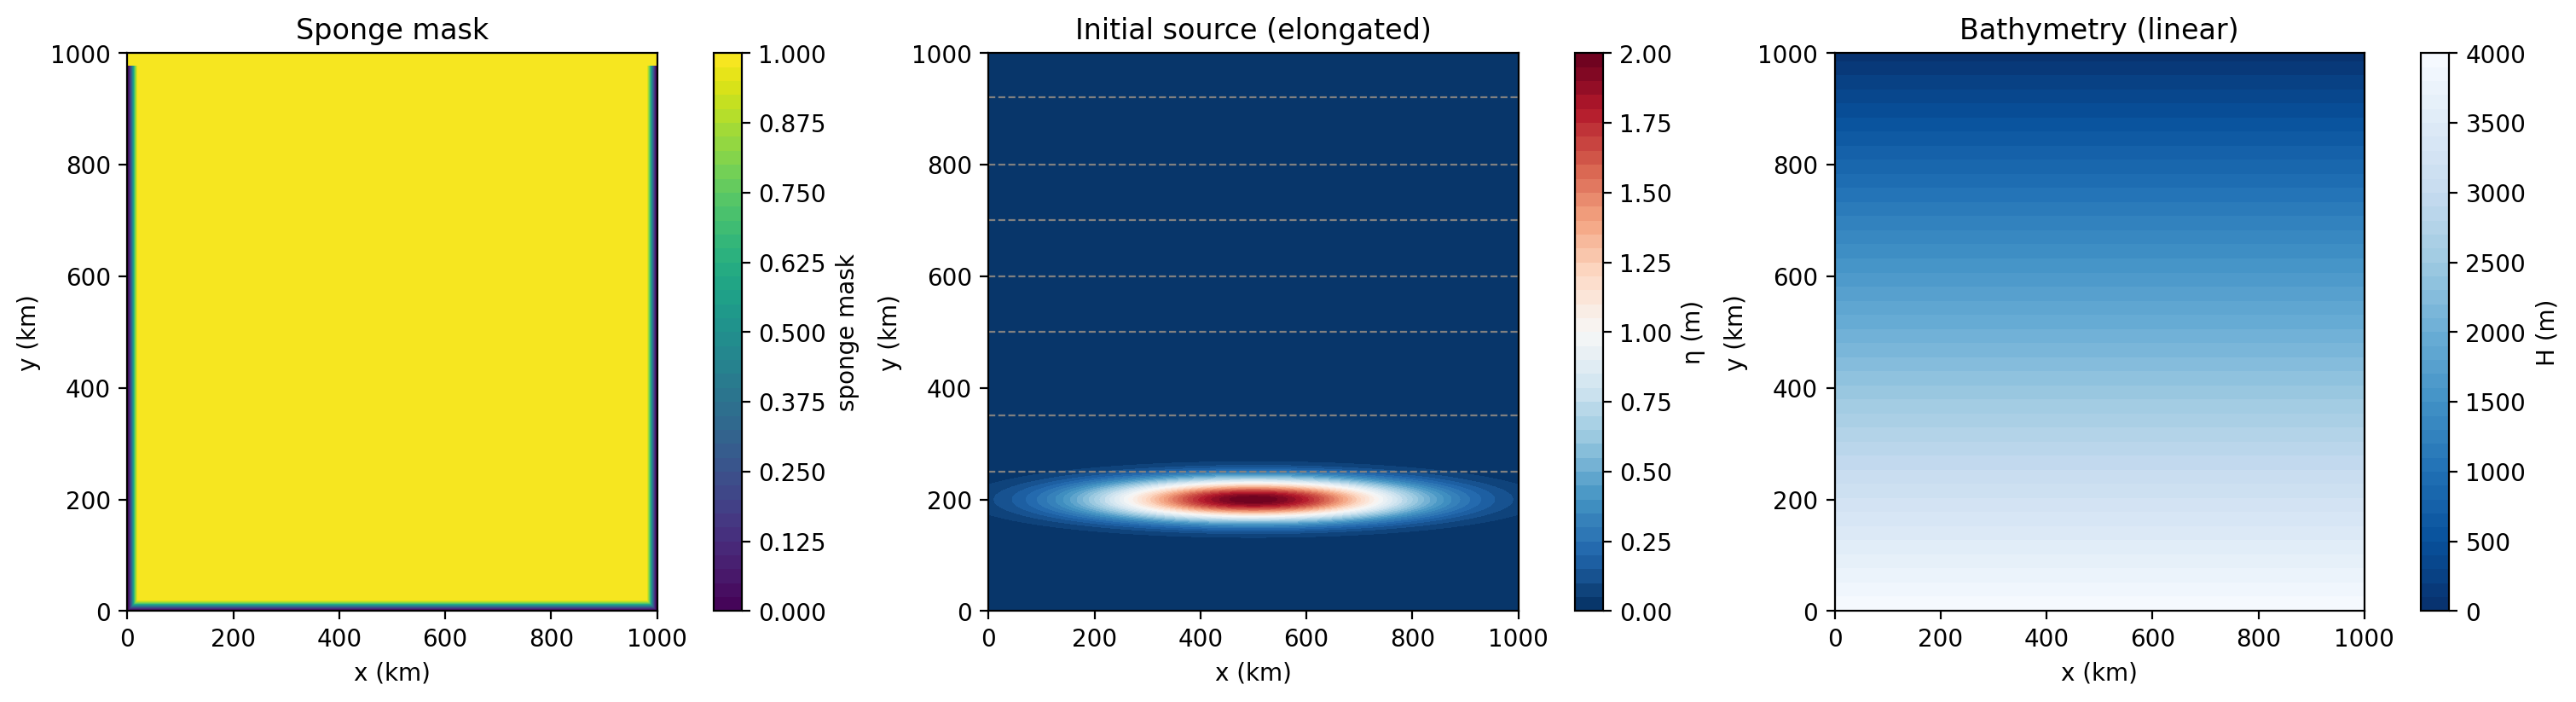

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), dpi=200, constrained_layout=True)

cf = axes[0].contourf(X/1e3, Y/1e3, mask, levels=40, cmap="viridis", vmin=0, vmax=1)
fig.colorbar(cf, ax=axes[0], label="sponge mask")
axes[0].set_title("Sponge mask")
axes[0].set_xlabel("x (km)"); axes[0].set_ylabel("y (km)")

cf = axes[1].contourf(X/1e3, Y/1e3, eta, levels=40, cmap="RdBu_r")
fig.colorbar(cf, ax=axes[1], label="η (m)")
axes[1].set_title(f"Initial source ({SOURCE})")
axes[1].set_xlabel("x (km)"); axes[1].set_ylabel("y (km)")
if COAST in ("top", "bottom"):
    for j in gauge_js:
        axes[1].axhline(y=y[j]/1e3, color='gray', linestyle='--', linewidth=0.8)
else:
    for j in gauge_js:
        axes[1].axvline(x=x[j]/1e3, color='gray', linestyle='--', linewidth=0.8)

cf = axes[2].contourf(X/1e3, Y/1e3, H, levels=40, cmap="Blues_r")
fig.colorbar(cf, ax=axes[2], label="H (m)")
axes[2].set_title(f"Bathymetry ({BATHY})")
axes[2].set_xlabel("x (km)"); axes[2].set_ylabel("y (km)")

plt.show()

## 1e. Run simulation

In [23]:
# warm-up (triggers Numba JIT compilation)
eta, u, v = step_maccormack(eta, u, v, H, dx, dy, dt, g, COAST_ID)
eta, u, v = apply_sponge(eta, u, v, mask)

gauge_t   = []
gauge_eta = {label: [] for label in gauge_labels}
coastal_amp = []

start = time.time()
for n in range(1, nt + 1):
    t = n * dt
    eta, u, v = step_maccormack(eta, u, v, H, dx, dy, dt, g, COAST_ID)
    eta, u, v = apply_sponge(eta, u, v, mask)

    gauge_t.append(t)
    for label, j in zip(gauge_labels, gauge_js):
        gauge_eta[label].append(get_gauge(eta, j))
    coastal_amp.append(get_coast_amp(eta))

    if n % 500 == 0:
        maxval = np.max(np.abs(eta))
        print(f"step={n:5d} | t={t:8.1f} s | max|eta|={maxval:.4e}")
        if maxval > 1e4 or np.isnan(maxval):
            print("Blowup!"); break

print(f"Runtime: {time.time()-start:.1f} s")

step=  500 | t=   561.5 s | max|eta|=9.9605e-01
step= 1000 | t=  1123.1 s | max|eta|=1.0003e+00
step= 1500 | t=  1684.6 s | max|eta|=1.0118e+00
step= 2000 | t=  2246.1 s | max|eta|=1.0306e+00
step= 2500 | t=  2807.7 s | max|eta|=1.0570e+00
step= 3000 | t=  3369.2 s | max|eta|=1.0914e+00
step= 3500 | t=  3930.7 s | max|eta|=1.1350e+00
step= 4000 | t=  4492.3 s | max|eta|=1.1899e+00
step= 4500 | t=  5053.8 s | max|eta|=1.2575e+00
step= 5000 | t=  5615.3 s | max|eta|=1.3435e+00
step= 5500 | t=  6176.9 s | max|eta|=1.4570e+00
step= 6000 | t=  6738.4 s | max|eta|=1.6057e+00
step= 6500 | t=  7299.9 s | max|eta|=1.8044e+00
step= 7000 | t=  7861.5 s | max|eta|=2.1467e+00
step= 7500 | t=  8423.0 s | max|eta|=1.4904e+00
step= 8000 | t=  8984.5 s | max|eta|=1.4425e+00
step= 8500 | t=  9546.1 s | max|eta|=1.0746e+00
Runtime: 25.1 s


## 1f. Compare results to analytical solutions for Green's law and wave speed

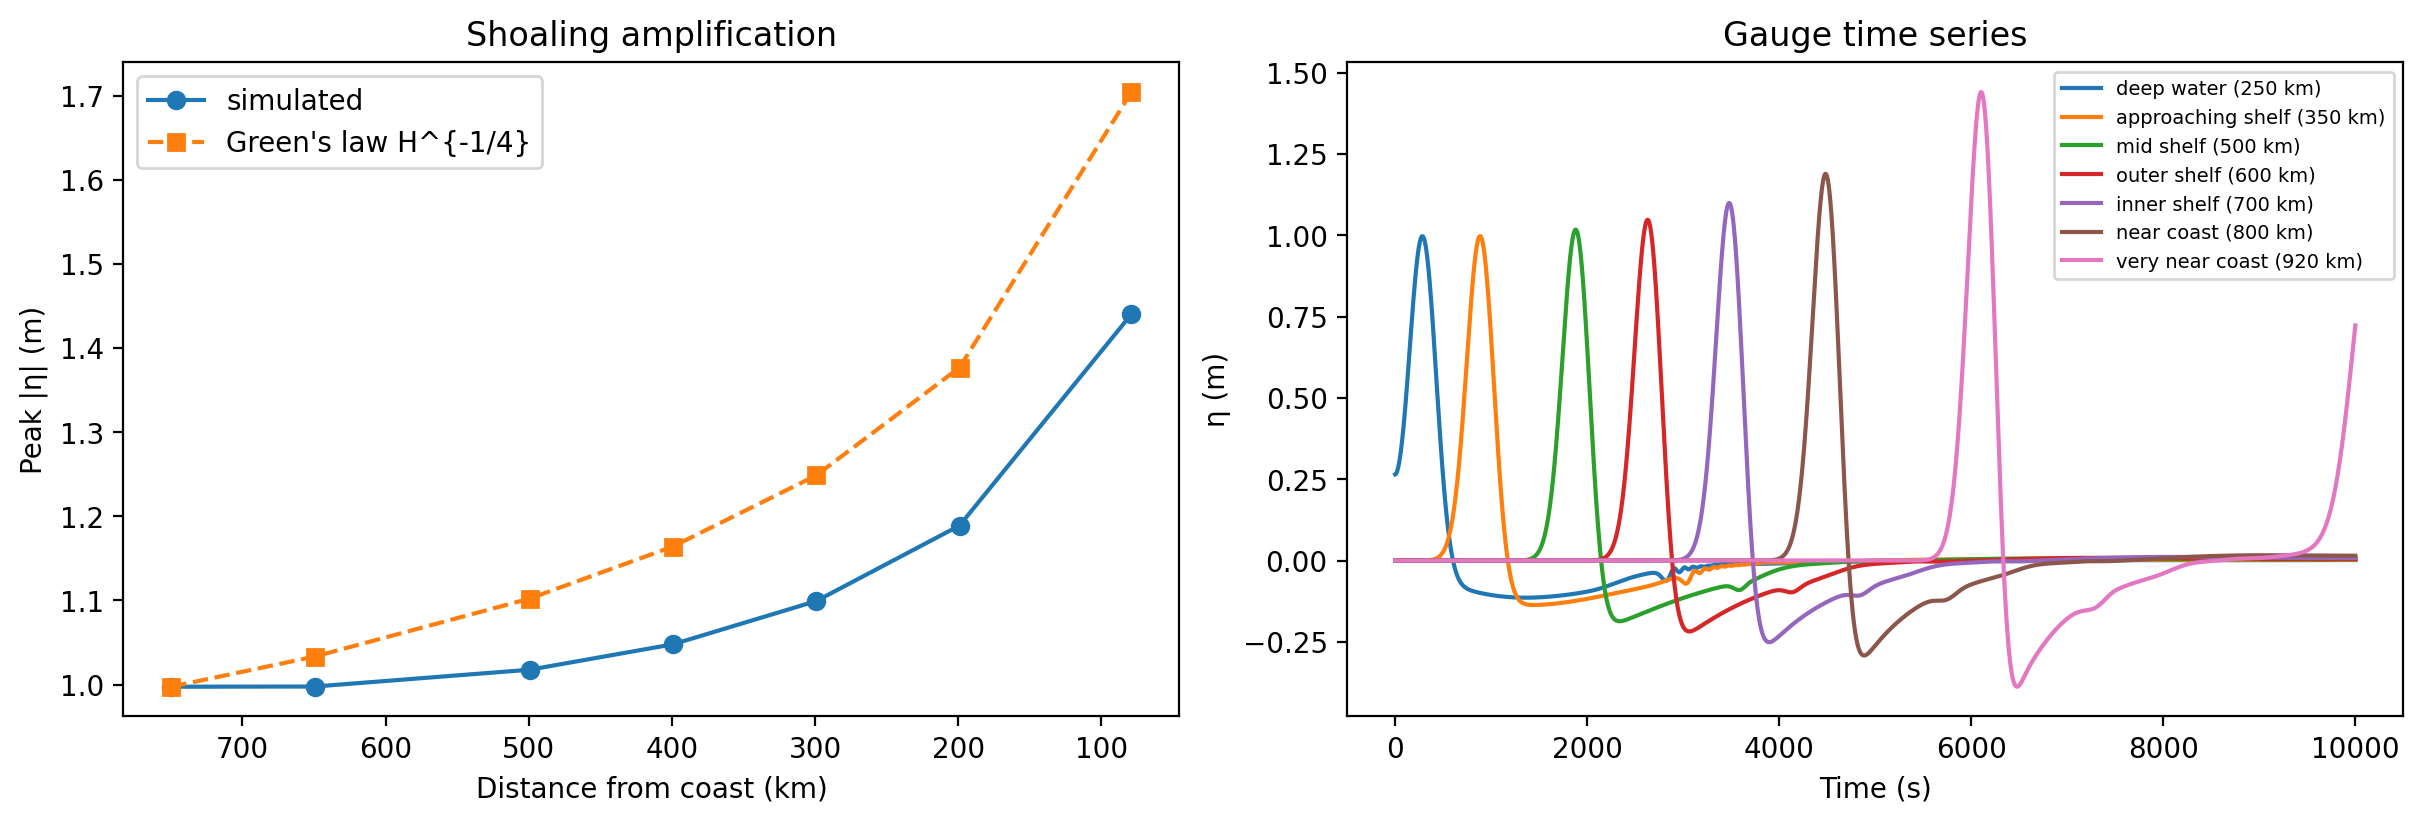

In [24]:
# Green's law comparison
peak_eta   = np.array([np.max(np.abs(gauge_eta[l])) for l in gauge_labels])
greens_law = peak_eta[0] * (H_at_gauges[0] / H_at_gauges)**0.25

fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=200, constrained_layout=True)

axes[0].plot(dist_km, peak_eta,   "o-",  label="simulated")
axes[0].plot(dist_km, greens_law, "s--", label="Green's law H^{-1/4}")
axes[0].invert_xaxis()
axes[0].set_xlabel("Distance from coast (km)")
axes[0].set_ylabel("Peak |η| (m)")
axes[0].set_title("Shoaling amplification")
axes[0].legend()

for label in gauge_labels:
    axes[1].plot(gauge_t, gauge_eta[label], label=label)
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("η (m)")
axes[1].set_title("Gauge time series")
axes[1].legend(fontsize=7)

plt.show()

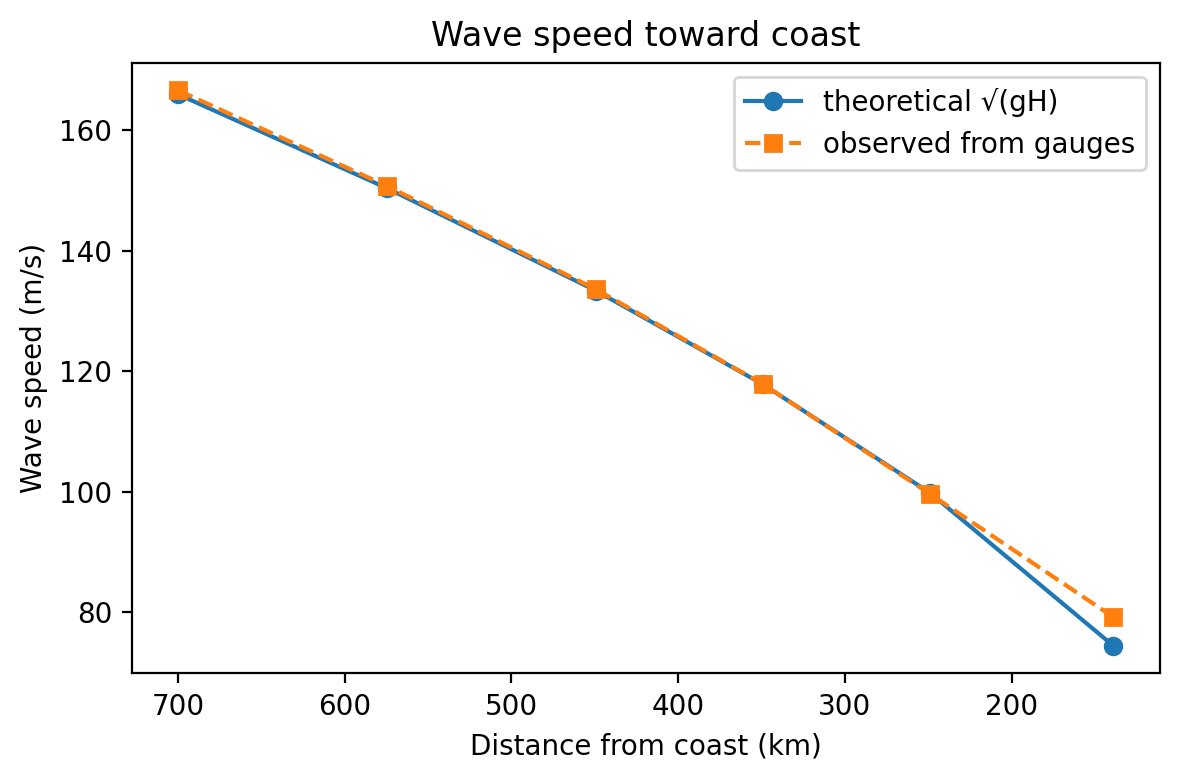

In [25]:
# Wave speed: theoretical vs observed from gauge arrival times
gauge_t_arr = np.array(gauge_t)
t_cutoff    = tmax * 0.6
idx_cut     = np.searchsorted(gauge_t_arr, t_cutoff)

arrival_t = np.array([
    gauge_t_arr[np.argmax(np.abs(gauge_eta[l][:idx_cut]))]
    for l in gauge_labels
])

if COAST in ("top", "bottom"):
    gauge_pos = np.array([y[j] for j in gauge_js])
else:
    gauge_pos = np.array([x[j] for j in gauge_js])

obs_speed  = np.abs(np.diff(gauge_pos)) / np.diff(arrival_t)
c_theory   = np.sqrt(g * H_at_gauges)
c_theo_mid = 0.5 * (c_theory[:-1] + c_theory[1:])
mid_dist   = dist_from_coast(0.5 * (pos_km[:-1] + pos_km[1:]))

fig, ax = plt.subplots(figsize=(6, 4), dpi=200)
ax.plot(mid_dist, c_theo_mid, "o-",  label="theoretical √(gH)")
ax.plot(mid_dist, obs_speed,  "s--", label="observed from gauges")
ax.invert_xaxis()
ax.set_xlabel("Distance from coast (km)")
ax.set_ylabel("Wave speed (m/s)")
ax.set_title("Wave speed toward coast")
ax.legend()
plt.tight_layout()
plt.show()

## 1g. OPTIONAL convergence test for simple case


--- Running Nx=Ny=300 ---
  Runtime: 0.9 s
  dx=3.34 km | peak=1.193 m | Green's=1.699 m | error=29.8%

--- Running Nx=Ny=600 ---
  Runtime: 6.0 s
  dx=1.67 km | peak=1.396 m | Green's=1.700 m | error=17.9%

--- Running Nx=Ny=900 ---
  Runtime: 26.1 s
  dx=1.11 km | peak=1.436 m | Green's=1.700 m | error=15.5%

--- Running Nx=Ny=1200 ---
  Runtime: 74.0 s
  dx=0.83 km | peak=1.448 m | Green's=1.700 m | error=14.8%

--- Running Nx=Ny=1500 ---
  Runtime: 157.5 s
  dx=0.67 km | peak=1.452 m | Green's=1.700 m | error=14.6%

--- Running Nx=Ny=1800 ---
  Runtime: 378.4 s
  dx=0.56 km | peak=1.454 m | Green's=1.700 m | error=14.5%

--- Running Nx=Ny=2100 ---
  Runtime: 1109.1 s
  dx=0.48 km | peak=1.456 m | Green's=1.700 m | error=14.4%

     N  dx (km)     peak   Greens  error %
--------------------------------------------
   300     3.34    1.193    1.699     29.8
   600     1.67    1.396    1.700     17.9
   900     1.11    1.436    1.700     15.5
  1200     0.83    1.448    1.700     14.

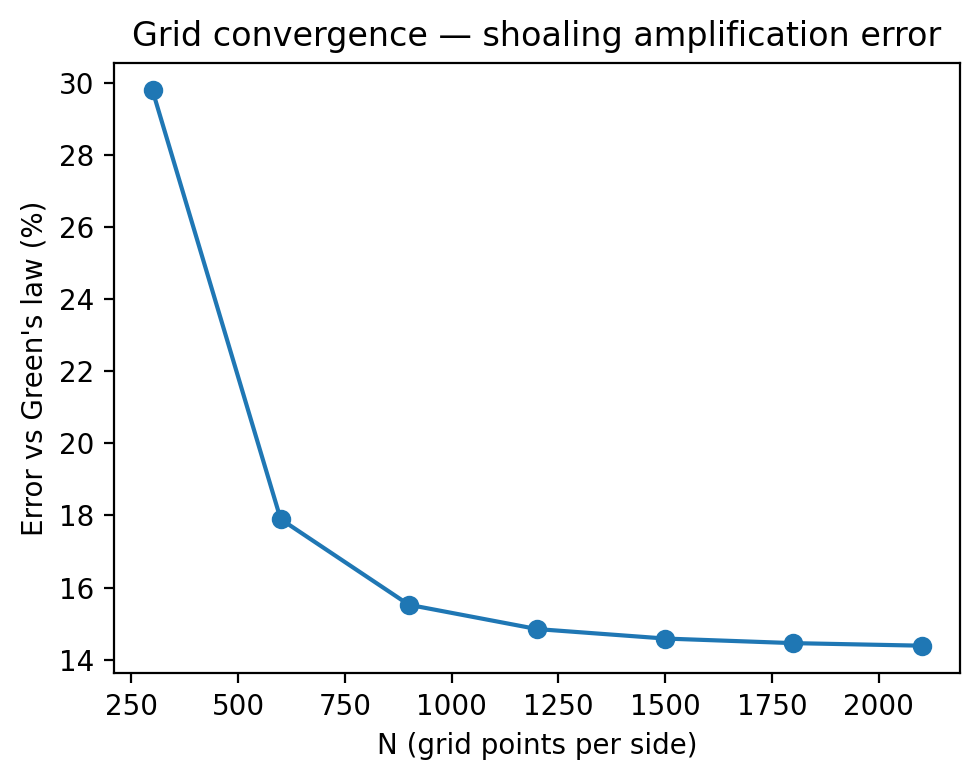

In [26]:
# OPTIONAL convergence test for simple case
#— takes several min. Only run when you want to check convergence.
# Skip this cell during normal runs.
# Hardcoded: linear bathy, elongated source, coast=top
if CONVERGENCE_TEST == True:
    _coast_id = 0  # top coast
    # _coast_id = 0
    x0, y0 = Lx/2, Ly*0.2   # source position for coast=top
    A      = 2.0
    
    resolutions = [300, 600, 900, 1200, 1500, 1800, 2100]
    convergence = []
    for N in resolutions:
        print(f"\n--- Running Nx=Ny={N} ---")
        dx_ = Lx / (N - 1)
        dy_ = Ly / (N - 1)
        X_, Y_ = np.meshgrid(np.linspace(0, Lx, N), np.linspace(0, Ly, N), indexing="ij")
        H_   = np.tile(np.linspace(H0, H_min, N), (N, 1))
        dt_  = CFL * min(dx_, dy_) / np.sqrt(g * np.max(H_))
        nt_  = int(tmax / dt_)
        eta_ = A * np.exp(-((X_ - x0)**2/(2*(Lx/5)**2) + (Y_ - y0)**2/(2*(Ly/40)**2)))
        u_   = np.zeros((N, N))
        v_   = np.zeros((N, N))
        mask_    = make_sponge(N, N, coast="top", width=20)
        gauge_i_ = N // 2
        gauge_j0_ = int(0.25 * (N - 1))
        gauge_j_  = int(0.92 * (N - 1))
        gauge_ref = []; gauge_near = []
        eta_, u_, v_ = step_maccormack(eta_, u_, v_, H_, dx_, dy_, dt_, g, _coast_id)
        eta_, u_, v_ = apply_sponge(eta_, u_, v_, mask_)
        start_ = time.time()
        for n in range(1, nt_ + 1):
            eta_, u_, v_ = step_maccormack(eta_, u_, v_, H_, dx_, dy_, dt_, g, _coast_id)
            eta_, u_, v_ = apply_sponge(eta_, u_, v_, mask_)
            gauge_ref.append(eta_[gauge_i_, gauge_j0_])
            gauge_near.append(eta_[gauge_i_, gauge_j_])
        peak_ref    = np.max(np.abs(gauge_ref))
        peak_near   = np.max(np.abs(gauge_near))
        greens_near = peak_ref * (H_[gauge_i_, gauge_j0_] / H_[gauge_i_, gauge_j_])**0.25
        err = (greens_near - peak_near) / greens_near * 100
        print(f"  Runtime: {time.time()-start_:.1f} s")
        print(f"  dx={dx_/1e3:.2f} km | peak={peak_near:.3f} m | Green's={greens_near:.3f} m | error={err:.1f}%")
        convergence.append((N, dx_/1e3, peak_near, greens_near, err))
    
    print(f"\n{'N':>6} {'dx (km)':>8} {'peak':>8} {'Greens':>8} {'error %':>8}")
    print("-" * 44)
    for row in convergence:
        print(f"{row[0]:>6} {row[1]:>8.2f} {row[2]:>8.3f} {row[3]:>8.3f} {row[4]:>8.1f}")
    
    plt.figure(figsize=(5, 4), dpi=200)
    plt.plot([c[0] for c in convergence], [c[4] for c in convergence], "o-")
    plt.xlabel("N (grid points per side)")
    plt.ylabel("Error vs Green's law (%)")
    plt.title("Grid convergence — shoaling amplification error")
    plt.tight_layout(); plt.show()

---
## Part 2: Mavericks model

Real GEBCO bathymetry, extended domain, land mask, wave focusing at Mavericks.


In [27]:
%reset -f
from tsunami_utils import step_maccormack, apply_sponge, make_sponge, smooth_1d
from scipy.interpolate import RegularGridInterpolator
from scipy.ndimage import gaussian_filter
import numpy as np
import matplotlib.pyplot as plt
import time

## 2a. Set problem and parameters

In [28]:
BATHY  = "real"      # real bathymetry
SOURCE = "circular"  # "circular" or "elongated"
COAST_ID = 3         # right/east coast, fixed for Mavericks

## 2b. Load GEBCO bathymetry file

In [29]:
with open("mavericks_bathy.nc", "rb") as f:
    raw = f.read()

n_lat, n_lon = 480, 720
n = n_lat * n_lon
elev_gebco  = np.frombuffer(raw[-n*2:], dtype=">i2").reshape(n_lat, n_lon).astype(float)
lon_gebco   = np.linspace(-124.5, -121.5, n_lon)
lat_gebco   = np.linspace(36.5,   38.5,   n_lat)

Lx_gebco = 3.0 * 111000 * np.cos(np.radians(37.5))
Ly_gebco = 2.0 * 111000

depth_gebco = np.where(elev_gebco < 0, -elev_gebco, 0.0)
land_gebco  = (elev_gebco >= 0).astype(float)

lat_mav = 37.495; lon_mav = -122.502
x_mav_g = (lon_mav - lon_gebco[0]) / (lon_gebco[-1] - lon_gebco[0]) * Lx_gebco
y_mav_g = (lat_mav - lat_gebco[0]) / (lat_gebco[-1] - lat_gebco[0]) * Ly_gebco

print(f"GEBCO loaded: {n_lat}x{n_lon}, max depth={depth_gebco.max():.0f} m")
print(f"Mavericks: x={x_mav_g/1e3:.1f} km, y={y_mav_g/1e3:.1f} km")

GEBCO loaded: 480x720, max depth=4156 m
Mavericks: x=175.9 km, y=110.4 km


## 2c. Set up grid and bathymetry

In [30]:
g = 9.81; H0 = 4000.0; H_min = 200.0; A = 2.0; CFL = 0.1; tmax = 4000.0

Lx_extra = 300e3
Lx = Lx_extra + Lx_gebco
Ly = Ly_gebco
Nx = 700; Ny = int(Nx * Ly / Lx)

dx = Lx/(Nx-1); dy = Ly/(Ny-1)
x  = np.linspace(0, Lx, Nx)
y  = np.linspace(0, Ly, Ny)
X, Y = np.meshgrid(x, y, indexing="ij")
xi_g = X - Lx_extra
in_gebco = (xi_g >= 0) & (xi_g <= Lx_gebco)

H = H0 * np.ones((Nx, Ny))
land_model = np.zeros((Nx, Ny), dtype=bool)

if BATHY == "real":
    interp_depth = RegularGridInterpolator(
        (np.linspace(0, Ly_gebco, n_lat), np.linspace(0, Lx_gebco, n_lon)),
        depth_gebco, method="linear", bounds_error=False, fill_value=H0)
    vals = interp_depth(np.stack([Y[in_gebco], xi_g[in_gebco]], axis=-1))
    vals = np.where(vals < H_min, H_min, vals)
    H_flat = H.ravel(); H_flat[in_gebco.ravel()] = vals
    H = np.clip(gaussian_filter(H_flat.reshape(Nx, Ny), sigma=2), H_min, None)

    interp_land = RegularGridInterpolator(
        (np.linspace(0, Ly_gebco, n_lat), np.linspace(0, Lx_gebco, n_lon)),
        land_gebco, method="nearest", bounds_error=False, fill_value=0.0)
    pts = np.stack([Y.ravel(), np.clip(xi_g, 0, Lx_gebco).ravel()], axis=-1)
    land_model = (interp_land(pts).reshape(Nx, Ny) > 0.5) & in_gebco

    H = np.clip(gaussian_filter(H, sigma=3), H_min, None)
    for j in range(Ny):
        ocean = ~land_model[:, j]
        deep  = np.where((H[:, j] >= 500.0) & ocean)[0]
        if len(deep):
            i0 = deep[-1]
            H[i0:, j] = np.linspace(500.0, H_min, Nx - i0)
    H = np.clip(gaussian_filter(H, sigma=1), H_min, None)
    H[land_model] = H0


## 2d. Source and sponge boundaries

In [31]:
y0_src = Ly / 2
arg = -((X - 50e3)**2 + (Y - y0_src)**2) / (2.0*(20e3)**2)
eta = A * np.exp(np.clip(arg, -500, 0))
eta[land_model] = 0.0
u   = np.zeros((Nx, Ny))
v   = np.zeros((Nx, Ny))

gauge_is     = [int(f*Nx) for f in [0.05, 0.15, 0.30, 0.50, 0.65, 0.80, 0.95]]
gauge_labels = [f"x={x[i]/1e3:.0f} km" for i in gauge_is]

def get_coast_amp(e):
    return np.max(np.abs(np.array([e[coast_i[j], j] for j in range(Ny)])))

mask = make_sponge(Nx, Ny, coast="right")
print("Source and sponge ready.")

Source and sponge ready.


## 2e. Run simulation

In [32]:
y_mav        = y_mav_g
x_mav        = x_mav_g + Lx_extra
j_mav        = int(np.clip(np.searchsorted(y, y_mav), 0, Ny-1))
COAST_ID     = 3
gauge_fracs  = [0.05, 0.15, 0.30, 0.50, 0.65, 0.80, 0.95]
gauge_is     = [int(f * Nx) for f in gauge_fracs]
gauge_labels = [f"x={x[i]/1e3:.0f} km" for i in gauge_is]
coast_i      = np.zeros(Ny, dtype=int)
for j in range(Ny):
    lc = np.where(land_model[:, j])[0]
    coast_i[j] = max(lc[0]-1, 0) if len(lc) else Nx-2

def get_coast_amp(e):
    return np.max(np.abs(np.array([e[coast_i[j], j] for j in range(Ny)])))

CFL  = 0.1
tmax = 4000.0
dt   = CFL * min(dx, dy) / np.sqrt(g * np.max(H))
nt   = int(tmax / dt)
print(f"dt={dt:.3f} s | nt={nt}")

eta, u, v = step_maccormack(eta, u, v, H, dx, dy, dt, g, COAST_ID)
eta, u, v = apply_sponge(eta, u, v, mask)
eta[land_model]=0.; u[land_model]=0.; v[land_model]=0.

snapshot_times = list(range(0, int(tmax)+1, 200))
snapshots      = {0: eta.copy()}
gauge_t        = []
gauge_eta      = {label: [] for label in gauge_labels}
coastal_amp    = []

start = time.time()
for n in range(1, nt+1):
    t = n * dt
    eta, u, v = step_maccormack(eta, u, v, H, dx, dy, dt, g, COAST_ID)
    eta, u, v = apply_sponge(eta, u, v, mask)
    eta[land_model]=0.; u[land_model]=0.; v[land_model]=0.

    gauge_t.append(t)
    for label, gi in zip(gauge_labels, gauge_is):
        gauge_eta[label].append(eta[gi, j_mav])
    coastal_amp.append(get_coast_amp(eta))

    for tsnap in snapshot_times:
        if tsnap not in snapshots and t >= tsnap:
            snapshots[tsnap] = eta.copy()

    if n % 50 == 0:
        maxval = np.max(np.abs(eta))
        print(f"step={n:5d} | t={t:8.1f} s | max|eta|={maxval:.4e}")
        if maxval > 1e4 or np.isnan(maxval):
            print("Blowup!"); break

print(f"Runtime: {time.time()-start:.1f} s")

dt=0.403 s | nt=9929
step=   50 | t=    20.1 s | max|eta|=1.9184e+00
step=  100 | t=    40.3 s | max|eta|=1.6927e+00
step=  150 | t=    60.4 s | max|eta|=1.3567e+00
step=  200 | t=    80.6 s | max|eta|=9.5810e-01
step=  250 | t=   100.7 s | max|eta|=6.6785e-01
step=  300 | t=   120.8 s | max|eta|=6.2162e-01
step=  350 | t=   141.0 s | max|eta|=6.0775e-01
step=  400 | t=   161.1 s | max|eta|=5.5676e-01
step=  450 | t=   181.3 s | max|eta|=6.1004e-01
step=  500 | t=   201.4 s | max|eta|=6.9127e-01
step=  550 | t=   221.6 s | max|eta|=6.8869e-01
step=  600 | t=   241.7 s | max|eta|=6.4198e-01
step=  650 | t=   261.8 s | max|eta|=5.8430e-01
step=  700 | t=   282.0 s | max|eta|=5.3068e-01
step=  750 | t=   302.1 s | max|eta|=4.8622e-01
step=  800 | t=   322.3 s | max|eta|=4.5040e-01
step=  850 | t=   342.4 s | max|eta|=4.2131e-01
step=  900 | t=   362.5 s | max|eta|=3.9719e-01
step=  950 | t=   382.7 s | max|eta|=3.7675e-01
step= 1000 | t=   402.8 s | max|eta|=3.5911e-01
step= 1050 | t=   4

## 2f. Plot coastal focusing 

Peak coastal amplitude: 0.734 m at y=106.1 km
Mavericks at y=111.0 km


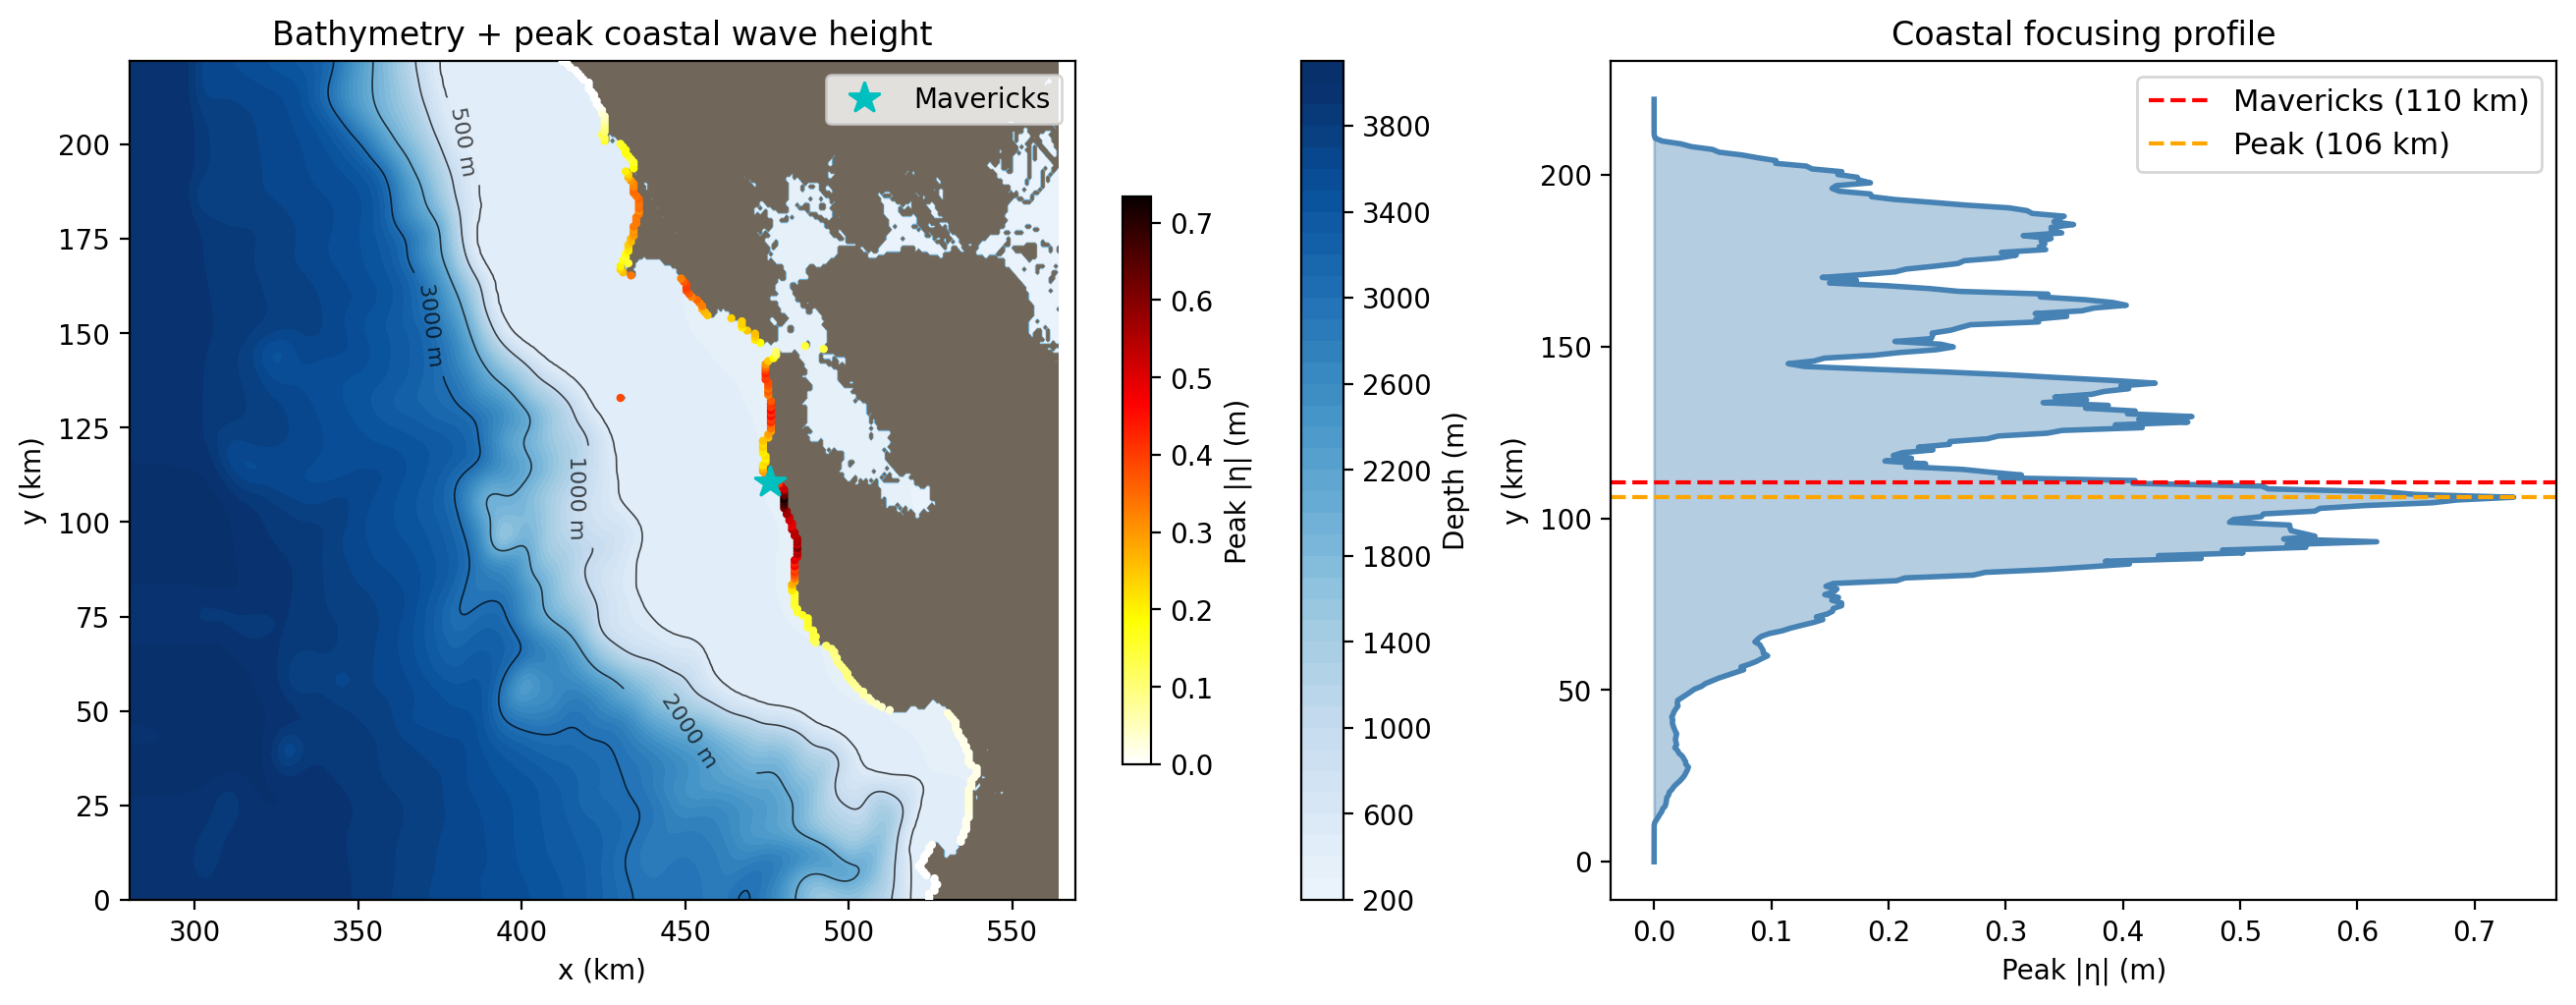

In [33]:
peak_coastal = np.zeros(Ny)
for j in range(Ny):
    peak_coastal[j] = max(abs(snapshots[t][coast_i[j], j]) for t in sorted(snapshots))
peak_smooth = smooth_1d(peak_coastal, size=7)
peak_j      = np.argmax(peak_smooth)

print(f"Peak coastal amplitude: {peak_smooth.max():.3f} m at y={y[peak_j]/1e3:.1f} km")
print(f"Mavericks at y={y[j_mav]/1e3:.1f} km")

fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=200, constrained_layout=True)

cf = axes[0].contourf(X/1e3, Y/1e3, H, levels=40, cmap="Blues", vmin=0, vmax=H0)
fig.colorbar(cf, ax=axes[0], label="Depth (m)")
if BATHY == "real":
    axes[0].contourf(X/1e3, Y/1e3, land_model.astype(float),
                     levels=[0.5, 1.5], colors=["#8B7355"], alpha=0.8)
coast_x = np.array([x[coast_i[j]] for j in range(Ny)]) / 1e3

H_ocean = np.where(land_model, np.nan, H)
cs = axes[0].contour(X/1e3, Y/1e3, H_ocean,
                     levels=[500, 1000, 2000, 3000],
                     colors='k', linewidths=0.6, alpha=0.7)
axes[0].clabel(cs, fmt='%d m', fontsize=8, inline=True, colors='k')

sc = axes[0].scatter(coast_x, y/1e3, c=peak_smooth, cmap="hot_r",
                     s=4, zorder=5, vmin=0, vmax=max(peak_smooth.max(), 1e-6))
fig.colorbar(sc, ax=axes[0], label="Peak |η| (m)", fraction=0.03)
axes[0].plot(x_mav/1e3, y_mav/1e3, "c*", markersize=12, zorder=6, label="Mavericks")
axes[0].set_xlim(Lx_extra/1e3-20, Lx/1e3+5)
axes[0].set_xlabel("x (km)"); axes[0].set_ylabel("y (km)")
axes[0].set_title("Bathymetry + peak coastal wave height")
axes[0].legend(fontsize=10)

axes[1].fill_betweenx(y/1e3, 0, peak_smooth, alpha=0.4, color="steelblue")
axes[1].plot(peak_smooth, y/1e3, color="steelblue", linewidth=2)
axes[1].axhline(y_mav/1e3, color="r", linestyle="--", linewidth=1.5,
                label=f"Mavericks ({y_mav/1e3:.0f} km)")
axes[1].axhline(y[peak_j]/1e3, color="orange", linestyle="--", linewidth=1.5,
                label=f"Peak ({y[peak_j]/1e3:.0f} km)")
axes[1].set_xlabel("Peak |η| (m)"); axes[1].set_ylabel("y (km)")
axes[1].set_title("Coastal focusing profile")
axes[1].legend(fontsize=11)
plt.show()

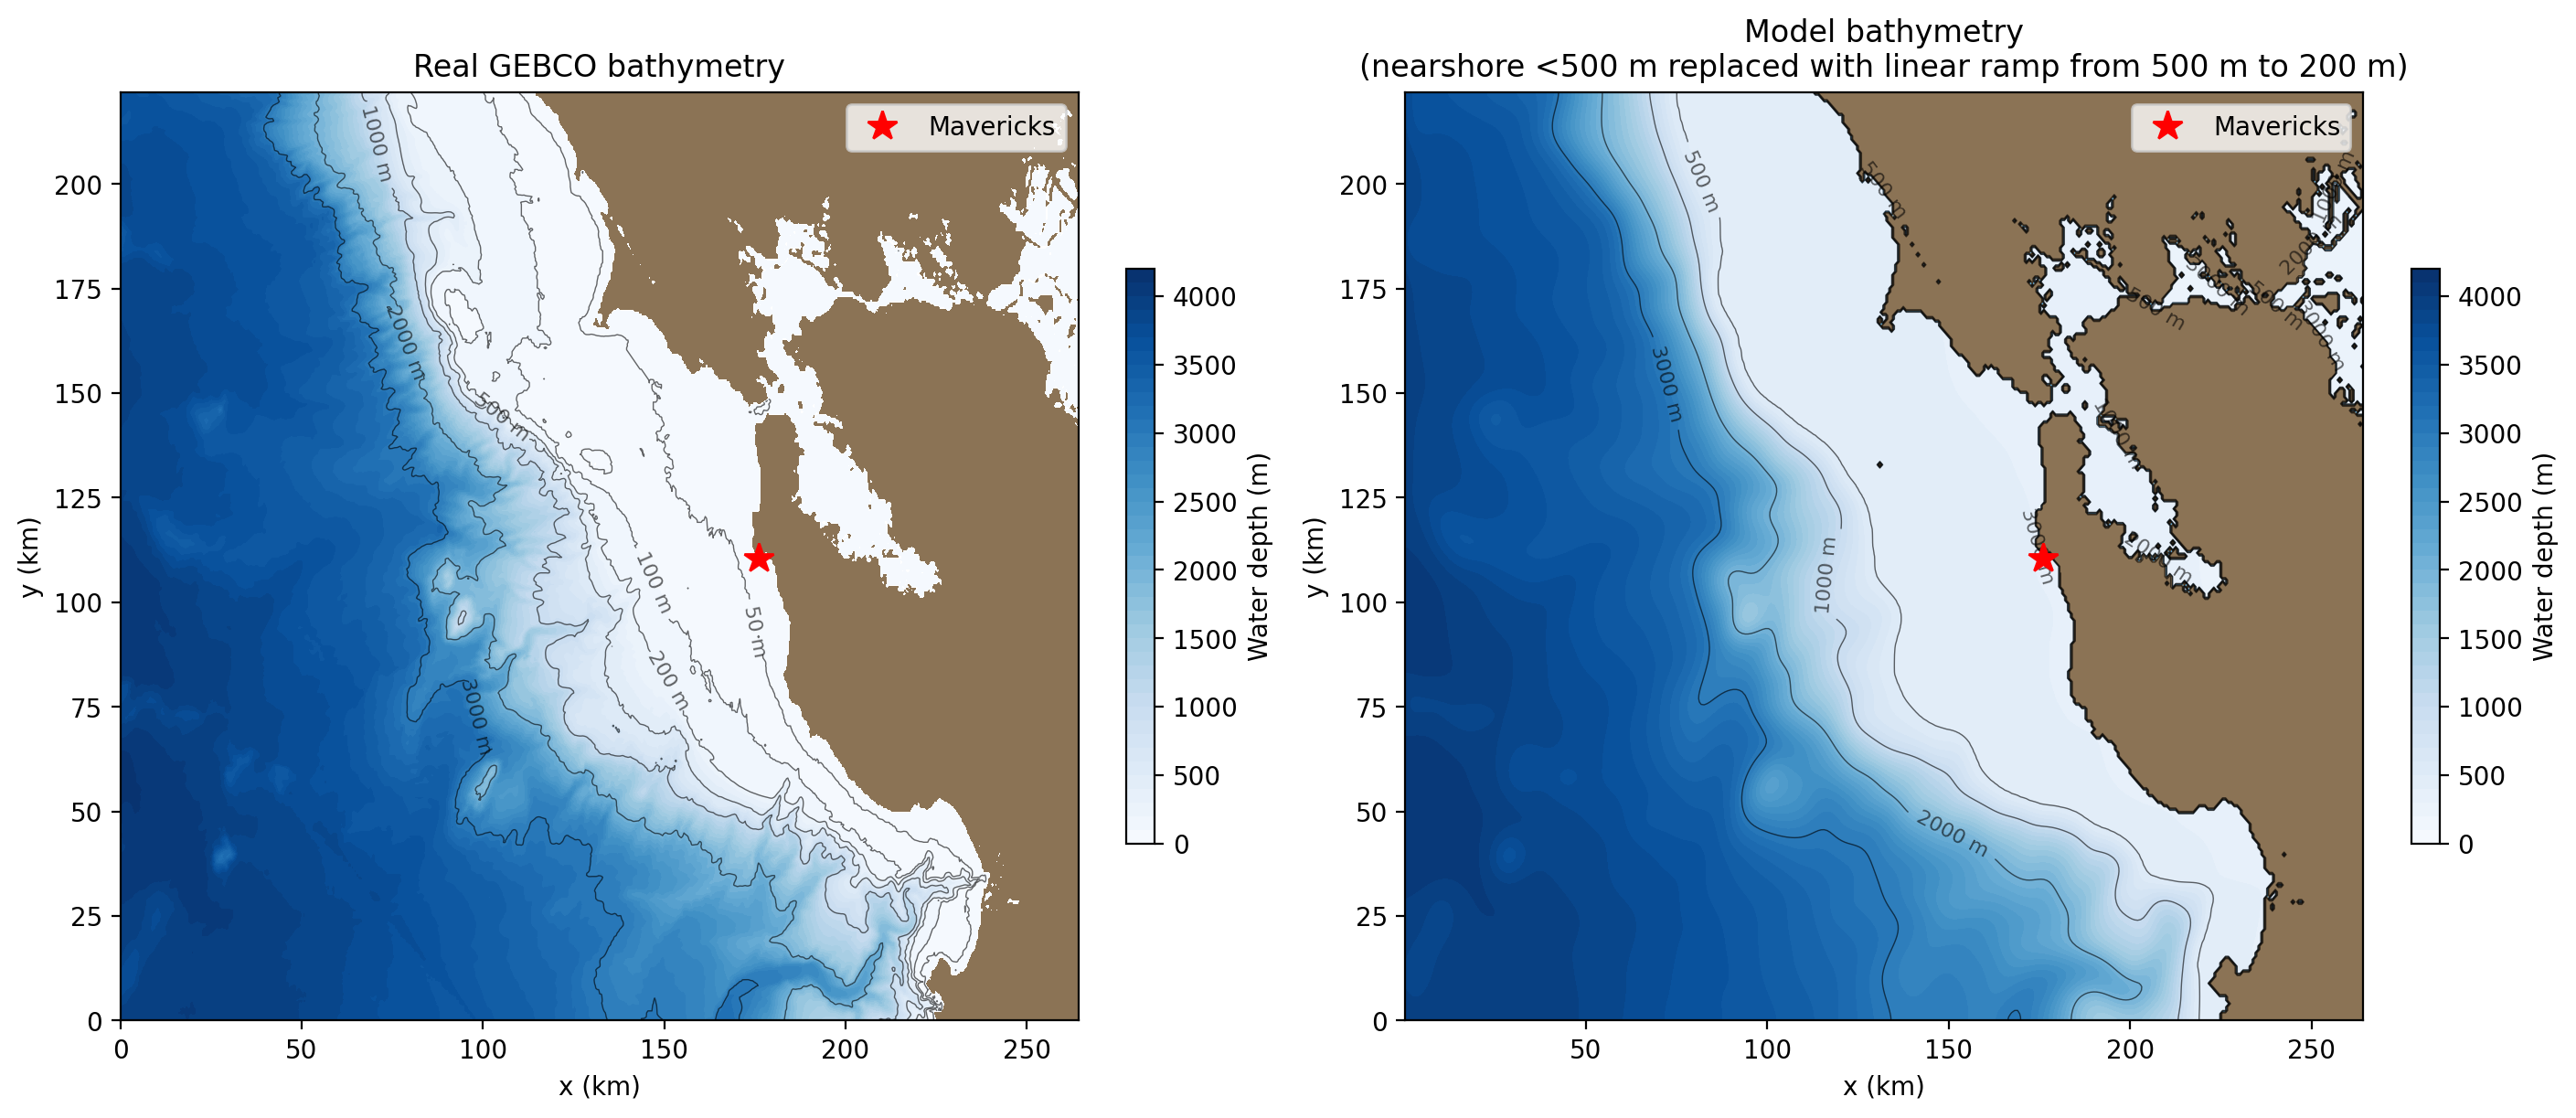

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=200, constrained_layout=True)

XX, YY = np.meshgrid(np.linspace(0, Lx_gebco/1e3, n_lon),
                     np.linspace(0, Ly_gebco/1e3, n_lat))

ocean_mask = elev_gebco < 0

# LEFT: real GEBCO depth
cf = axes[0].contourf(XX, YY, np.where(ocean_mask, -elev_gebco, np.nan),
                      levels=np.linspace(0, 4200, 43), cmap='Blues')
fig.colorbar(cf, ax=axes[0], label='Water depth (m)', fraction=0.03)
axes[0].contourf(XX, YY, np.where(~ocean_mask, 1, np.nan),
                 levels=[0.5, 1.5], colors=['#8B7355'])
cs = axes[0].contour(XX, YY, np.where(ocean_mask, -elev_gebco, np.nan),
                     levels=[50, 100, 200, 500, 1000, 2000, 3000],
                     colors='black', linewidths=0.5, alpha=0.6)
axes[0].clabel(cs, fmt='%d m', fontsize=8, colors='black')
axes[0].plot(x_mav_g/1e3, y_mav_g/1e3, 'r*', markersize=12, zorder=5, label='Mavericks')
axes[0].set_title('Real GEBCO bathymetry')
axes[0].set_xlabel('x (km)'); axes[0].set_ylabel('y (km)')
axes[0].legend(fontsize=10, loc='upper right')

# RIGHT: model bathymetry (GEBCO portion only, remapped to same coords)
i_start = np.searchsorted(x, Lx_extra)
x_km = (x[i_start:] - Lx_extra) / 1e3
Xm, Ym = np.meshgrid(x_km, y/1e3, indexing='ij')

cf = axes[1].contourf(Xm, Ym, H[i_start:, :],
                      levels=np.linspace(0, 4200, 43), cmap='Blues')
fig.colorbar(cf, ax=axes[1], label='Water depth (m)', fraction=0.03)
axes[1].contourf(Xm, Ym, land_model[i_start:, :].astype(float),
                 levels=[0.5, 1.5], colors=['#8B7355'])
cs = axes[1].contour(Xm, Ym, H[i_start:, :],
                     levels=[50, 100, 200, 500, 1000, 2000, 3000],
                     colors='black', linewidths=0.5, alpha=0.6)
axes[1].clabel(cs, fmt='%d m', fontsize=8, colors='black')
axes[1].plot(x_mav_g/1e3, y_mav_g/1e3, 'r*', markersize=12, zorder=5, label='Mavericks')
axes[1].set_title('Model bathymetry\n(nearshore <500 m replaced with linear ramp from 500 m to 200 m)')
axes[1].set_xlabel('x (km)'); axes[1].set_ylabel('y (km)')
axes[1].legend(fontsize=10, loc='upper right')

plt.show()



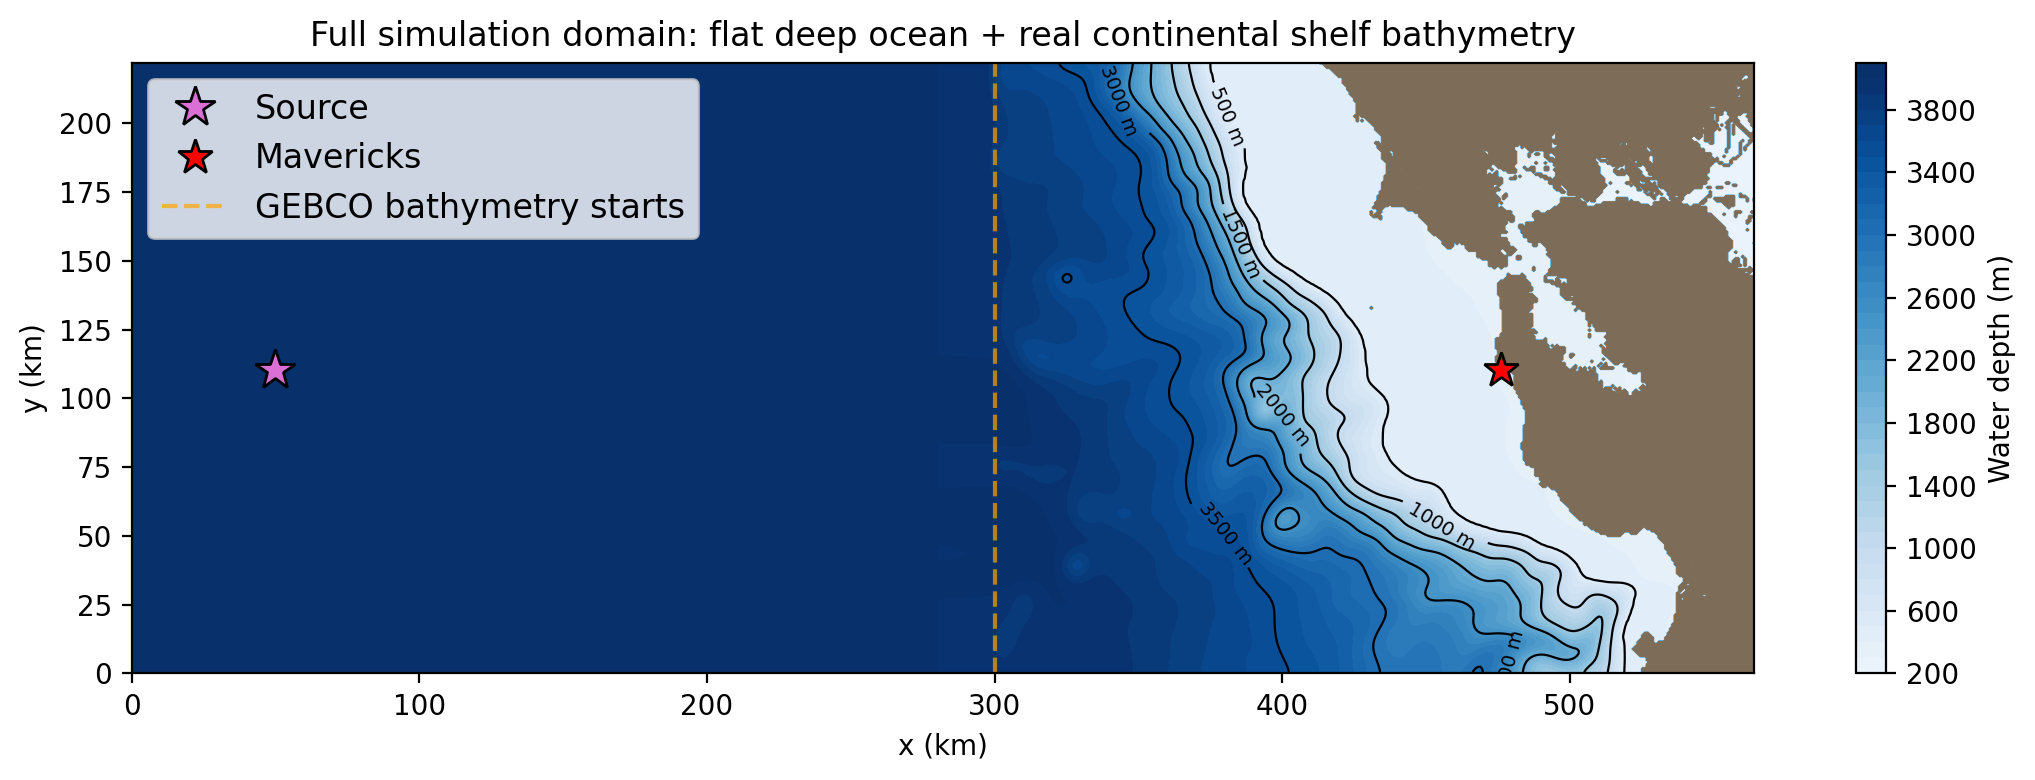

In [35]:
fig, ax = plt.subplots(figsize=(11, 4), dpi=200)

cf = ax.contourf(X/1e3, Y/1e3, H, levels=40, cmap='Blues', vmin=0, vmax=H0)
fig.colorbar(cf, ax=ax, label='Water depth (m)')

if BATHY == 'real':
    ax.contourf(X/1e3, Y/1e3, land_model.astype(float),
                levels=[0.5, 1.5], colors=['#8B7355'], alpha=0.9)

# isobaths — mask land so no contours over brown area
H_ocean = np.where(land_model, np.nan, H)
cs = ax.contour(X/1e3, Y/1e3, H_ocean, levels=[200, 500, 1000,1500, 2000,2500, 3000, 3500], colors='k', linewidths=0.8)
ax.clabel(cs, fmt='%d m', fontsize=7, inline=True, colors='k')

# source
ax.plot(50, y_mav/1e3, '*',markerfacecolor='orchid', markersize=15,  markeredgecolor='k', zorder=6, label='Source')

# Mavericks
ax.plot(x_mav/1e3, y_mav/1e3, 'r*', markersize=13, markeredgecolor='k', zorder=6, label='Mavericks')
ax.axvline(x=Lx_extra/1e3, color='orange', linestyle='--',linewidth=1.5, alpha=0.7, label='GEBCO bathymetry starts')
ax.set_xlabel('x (km)')
ax.set_ylabel('y (km)')
ax.set_title('Full simulation domain: flat deep ocean + real continental shelf bathymetry')
ax.legend(fontsize=12, loc='upper left')
plt.tight_layout()
plt.show()

## 